## 0. Environment Setup

In [1]:
import warnings
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from scipy import stats
from scipy.optimize import minimize

warnings.filterwarnings("ignore")
plt.style.use("dark_background")

COLORS = {
    "primary": "#4FC3F7",
    "success": "#66BB6A",
    "danger": "#EF5350",
    "warning": "#FFA726",
    "neutral": "#B0BEC5",
    "accent": "#AB47BC",
}

# ── V3 Safety Thresholds (calibrate against these) ──────────────────────────
UNCERTAINTY_CRITICAL = 0.80
MAX_DRAWDOWN_LIMIT = 0.10
DAILY_LOSS_LIMIT = 0.03
PROFIT_TARGET = 0.20

# ── Portfolio definition (GNN node universe §3-C) ──────────────────────────
PORTFOLIO = {
    "SPY": 0.30,
    "AAPL": 0.15,
    "MSFT": 0.15,
    "NVDA": 0.10,
    "GLD": 0.10,
    "TLT": 0.10,
    "AMD": 0.05,
    "QQQ": 0.05,
}
PORTFOLIO_VALUE = 100_000.0  # $100k starting capital

END = datetime.today()
START = END - timedelta(days=365 * 5)

print(
    f"Portfolio ({len(PORTFOLIO)} assets) | Capital: ${PORTFOLIO_VALUE:,.0f}"
)
print(
    f"Safety thresholds: uncertainty={UNCERTAINTY_CRITICAL} | "
    f"max_dd={MAX_DRAWDOWN_LIMIT:.0%} | daily_loss={DAILY_LOSS_LIMIT:.0%}"
)

Portfolio (8 assets) | Capital: $100,000
Safety thresholds: uncertainty=0.8 | max_dd=10% | daily_loss=3%


## 1. Portfolio Returns Construction

In [2]:
prices: dict[str, pd.Series] = {}
for ticker in PORTFOLIO:
    df = yf.download(
        ticker, start=START, end=END, progress=False, auto_adjust=True
    )
    prices[ticker] = df["Close"].squeeze()
    print(f"  {ticker:<6} → {len(df):>4} rows")

close_df = pd.DataFrame(prices).dropna()
returns = close_df.pct_change().dropna()

# Weighted portfolio returns
weights = pd.Series(PORTFOLIO)
weights = weights / weights.sum()  # normalise
portfolio_ret = (returns * weights).sum(axis=1)

print(f"\nPortfolio returns: {len(portfolio_ret)} daily observations")
print(f"  Mean (ann.)  : {portfolio_ret.mean() * 252:+.2%}")
print(f"  Std (ann.)   : {portfolio_ret.std() * np.sqrt(252):.2%}")
print(f"  Skewness     : {portfolio_ret.skew():.3f}")
print(f"  Kurtosis     : {portfolio_ret.kurtosis():.3f}")

  SPY    → 1255 rows


  AAPL   → 1255 rows


  MSFT   → 1255 rows


  NVDA   → 1255 rows


  GLD    → 1255 rows


  TLT    → 1255 rows


  AMD    → 1255 rows


  QQQ    → 1255 rows

Portfolio returns: 1254 daily observations
  Mean (ann.)  : +20.29%
  Std (ann.)   : 19.23%
  Skewness     : 0.444
  Kurtosis     : 7.116


## 2. Value at Risk — Three Methods

In [3]:
CONFIDENCE_LEVELS = [0.95, 0.99]


def var_historical(returns: pd.Series, confidence: float) -> float:
    """Historical VaR — non-parametric, directly from return distribution."""
    return -np.percentile(returns, (1 - confidence) * 100)


def var_parametric(returns: pd.Series, confidence: float) -> float:
    """Parametric (Gaussian) VaR — assumes normal distribution."""
    mu = returns.mean()
    std = returns.std()
    return -(mu + stats.norm.ppf(1 - confidence) * std)


def var_monte_carlo(
    returns: pd.Series,
    confidence: float,
    n_sims: int = 10_000,
    holding_period: int = 1,
) -> float:
    """
    Monte Carlo VaR — simulates correlated multi-asset paths.
    Used in backend/routes/risk.py for the /stress-test endpoint.
    """
    mu = returns.mean()
    sigma = returns.std()
    sims = np.random.normal(mu, sigma, n_sims)
    return -np.percentile(sims, (1 - confidence) * 100)


def cvar(returns: pd.Series, confidence: float) -> float:
    """CVaR (Expected Shortfall) — average loss beyond VaR."""
    var = var_historical(returns, confidence)
    tail = returns[returns <= -var]
    return -tail.mean() if len(tail) > 0 else var


print("VaR Summary (daily, single-day holding period):")
print(f"{'Method':<20} {'95% VaR':>10} {'99% VaR':>10} {'95% CVaR':>10}")
print("-" * 52)

for method_name, fn in [
    ("Historical", var_historical),
    ("Parametric", var_parametric),
    ("Monte Carlo", var_monte_carlo),
]:
    v95 = fn(portfolio_ret, 0.95)
    v99 = fn(portfolio_ret, 0.99)
    cv = cvar(portfolio_ret, 0.95)
    print(f"  {method_name:<18} {v95:>10.4f} {v99:>10.4f} {cv:>10.4f}")
    print(
        f"  {'($)':>18} {v95 * PORTFOLIO_VALUE:>10,.0f} "
        f"{v99 * PORTFOLIO_VALUE:>10,.0f} {cv * PORTFOLIO_VALUE:>10,.0f}"
    )

VaR Summary (daily, single-day holding period):
Method                  95% VaR    99% VaR   95% CVaR
----------------------------------------------------
  Historical             0.0189     0.0296     0.0269
                 ($)      1,894      2,962      2,685
  Parametric             0.0191     0.0274     0.0269
                 ($)      1,912      2,738      2,685
  Monte Carlo            0.0189     0.0273     0.0269
                 ($)      1,885      2,732      2,685


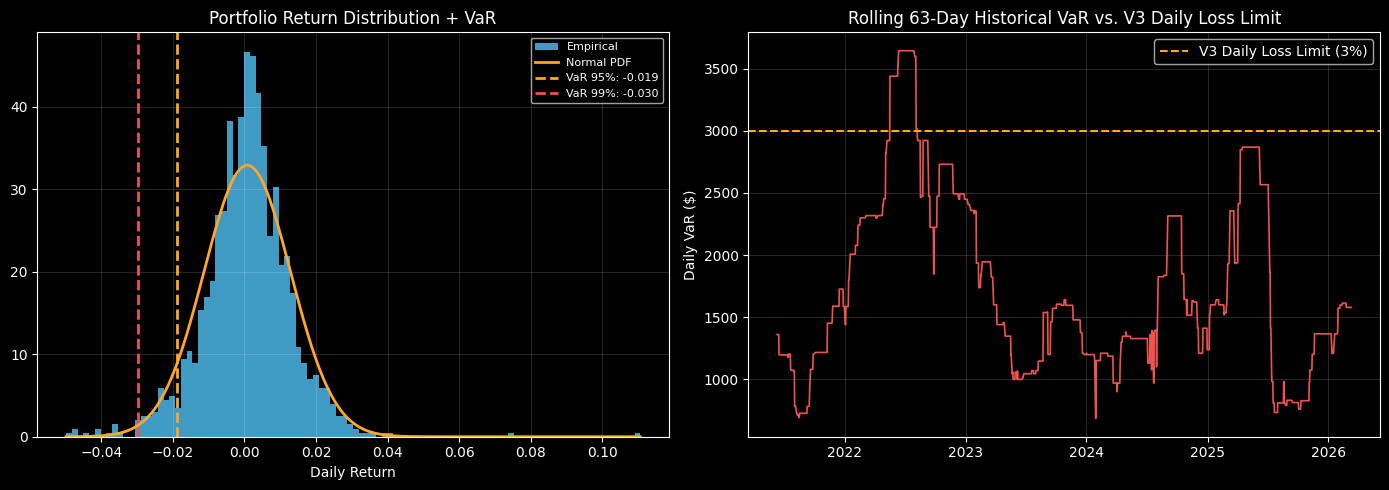

In [4]:
# VaR visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(
    portfolio_ret,
    bins=100,
    color=COLORS["primary"],
    alpha=0.8,
    density=True,
    label="Empirical",
)

# Overlay normal distribution
xs = np.linspace(portfolio_ret.min(), portfolio_ret.max(), 300)
ax.plot(
    xs,
    stats.norm.pdf(xs, portfolio_ret.mean(), portfolio_ret.std()),
    color=COLORS["warning"],
    linewidth=2,
    label="Normal PDF",
)

# VaR lines
for conf, color in zip(
    [0.95, 0.99], [COLORS["warning"], COLORS["danger"]], strict=False
):
    var95 = var_historical(portfolio_ret, conf)
    ax.axvline(
        -var95,
        color=color,
        linestyle="--",
        linewidth=2,
        label=f"VaR {conf:.0%}: {-var95:.3f}",
    )

ax.set_title("Portfolio Return Distribution + VaR")
ax.set_xlabel("Daily Return")
ax.legend(fontsize=8)
ax.grid(alpha=0.15)

# Rolling 21-day VaR
ax2 = axes[1]
rolling_var95 = portfolio_ret.rolling(63).apply(
    lambda r: var_historical(pd.Series(r), 0.95), raw=False
)
ax2.plot(
    rolling_var95.index,
    rolling_var95 * PORTFOLIO_VALUE,
    color=COLORS["danger"],
    linewidth=1.2,
)
ax2.axhline(
    DAILY_LOSS_LIMIT * PORTFOLIO_VALUE,
    color=COLORS["warning"],
    linestyle="--",
    linewidth=1.5,
    label=f"V3 Daily Loss Limit ({DAILY_LOSS_LIMIT:.0%})",
)
ax2.set_title("Rolling 63-Day Historical VaR vs. V3 Daily Loss Limit")
ax2.set_ylabel("Daily VaR ($)")
ax2.legend()
ax2.grid(alpha=0.15)

plt.tight_layout()
plt.savefig("05/05_var_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Stress Test Scenarios

In [5]:
# Historical crash events — used in
# backend/simulation/generators/scenario_loader.py and in the Spartan
# Curriculum Phase B adversarial training (§7-B).
STRESS_SCENARIOS = {
    "2008 Financial Crisis": ("2008-09-01", "2009-03-01"),
    "2020 COVID Crash": ("2020-02-19", "2020-03-23"),
    "2022 Rate Hike Bear": ("2022-01-03", "2022-10-12"),
    "2018 Q4 Correction": ("2018-10-01", "2018-12-24"),
    "2015 China Shock": ("2015-08-17", "2015-09-29"),
}

print(f"{'Scenario':<30} {'SPY Return':>12} {'Max DD':>10} {'Duration':>10}")
print("-" * 65)

spy_full = yf.download(
    "SPY", start="2008-01-01", end=END, progress=False, auto_adjust=True
)["Close"].squeeze()

scenario_results: list[dict] = []
for name, (start, end) in STRESS_SCENARIOS.items():
    segment = spy_full.loc[start:end]
    if len(segment) < 5:
        continue
    ret = segment.iloc[-1] / segment.iloc[0] - 1
    roll_max = segment.cummax()
    max_dd = ((segment - roll_max) / roll_max).min()
    duration = (pd.Timestamp(end) - pd.Timestamp(start)).days
    scenario_results.append(
        {
            "scenario": name,
            "return": ret,
            "max_dd": max_dd,
            "duration": duration,
            "portfolio_loss": ret
            * PORTFOLIO_VALUE
            * 0.5,  # assume 50% equity exposure
        }
    )
    print(f"  {name:<28} {ret:>12.2%} {max_dd:>10.2%} {duration:>8}d")

df_scenarios = pd.DataFrame(scenario_results)

Scenario                         SPY Return     Max DD   Duration
-----------------------------------------------------------------


  2008 Financial Crisis             -41.43%    -41.43%      181d
  2020 COVID Crash                  -33.72%    -33.72%       33d
  2022 Rate Hike Bear               -24.50%    -24.50%      282d
  2018 Q4 Correction                -19.20%    -19.20%       84d
  2015 China Shock                  -10.21%    -11.07%       43d


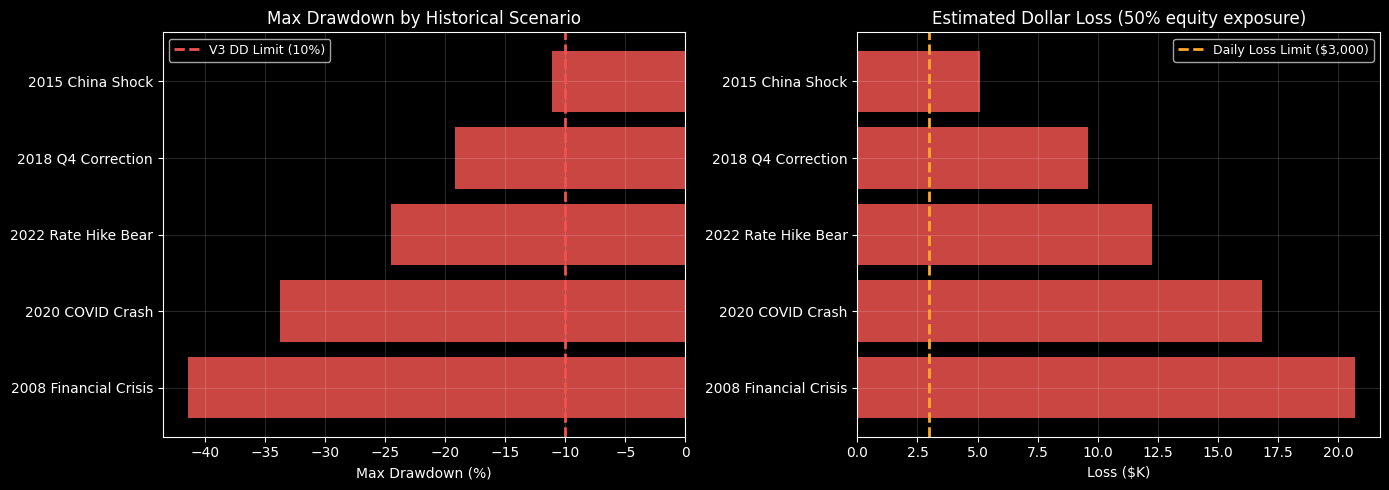

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scenario bar chart — portfolio impact
colors_bar = [
    COLORS["danger"] if r < -MAX_DRAWDOWN_LIMIT else COLORS["warning"]
    for r in df_scenarios["max_dd"]
]
axes[0].barh(
    df_scenarios["scenario"],
    df_scenarios["max_dd"] * 100,
    color=colors_bar,
    alpha=0.85,
)
axes[0].axvline(
    -MAX_DRAWDOWN_LIMIT * 100,
    color=COLORS["danger"],
    linestyle="--",
    linewidth=2,
    label=f"V3 DD Limit ({MAX_DRAWDOWN_LIMIT:.0%})",
)
axes[0].set_title("Max Drawdown by Historical Scenario")
axes[0].set_xlabel("Max Drawdown (%)")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.15)

# Dollar loss
axes[1].barh(
    df_scenarios["scenario"],
    df_scenarios["portfolio_loss"].abs() / 1000,
    color=colors_bar,
    alpha=0.85,
)
axes[1].axvline(
    DAILY_LOSS_LIMIT * PORTFOLIO_VALUE / 1000,
    color=COLORS["warning"],
    linestyle="--",
    linewidth=2,
    label=f"Daily Loss Limit (${DAILY_LOSS_LIMIT * PORTFOLIO_VALUE:,.0f})",
)
axes[1].set_title("Estimated Dollar Loss (50% equity exposure)")
axes[1].set_xlabel("Loss ($K)")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.15)

plt.tight_layout()
plt.savefig("05/05_stress_scenarios.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Portfolio Optimisation — Efficient Frontier

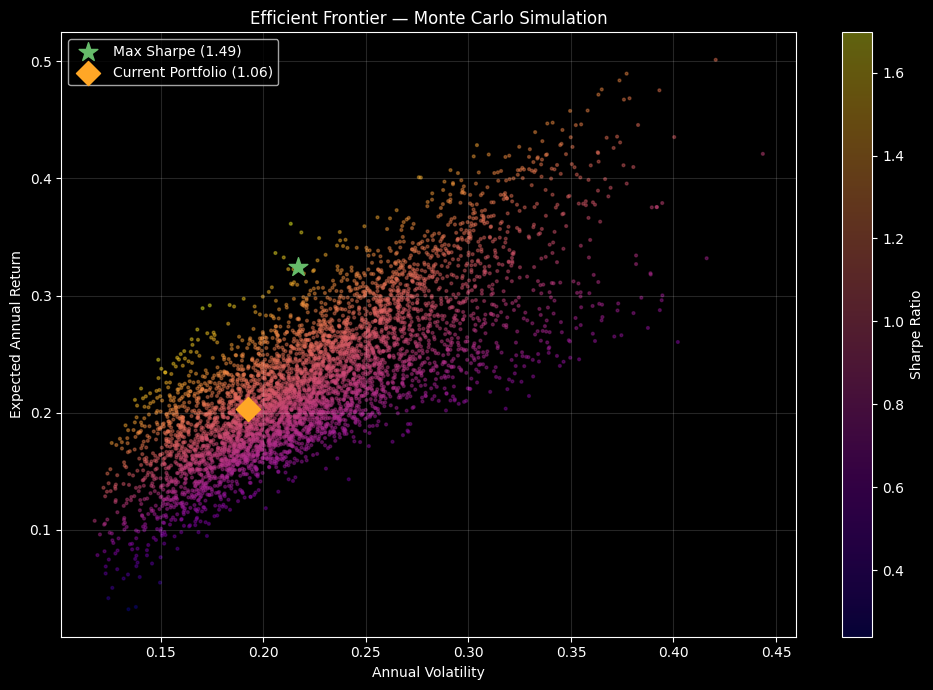


Max Sharpe Portfolio Weights:
  SPY   : 24.86%
  AAPL  : 11.00%
  MSFT  : 0.00%
  NVDA  : 30.00%
  GLD   : 30.00%
  TLT   : 4.14%
  AMD   : 0.00%
  QQQ   : 0.00%
  Sharpe: 1.492 | Return: 32.40% | Vol: 21.71%


In [7]:
# Markowitz efficient frontier — used to validate position sizing
# recommendations from the Kelly Criterion in
# backend/execution/logic/position_sizer.py

cov_matrix = returns.cov() * 252
mean_rets = returns.mean() * 252
n_assets = len(PORTFOLIO)


def portfolio_stats(w: np.ndarray) -> tuple[float, float, float]:
    """Return (expected return, volatility, Sharpe ratio)."""
    ret = np.dot(w, mean_rets)
    vol = np.sqrt(w @ cov_matrix.values @ w)
    sharpe = ret / vol if vol > 0 else 0
    return ret, vol, sharpe


# Monte Carlo frontier
N_MC_PORTFOLIOS = 5000
mc_rets = np.zeros(N_MC_PORTFOLIOS)
mc_vols = np.zeros(N_MC_PORTFOLIOS)
mc_sharpe = np.zeros(N_MC_PORTFOLIOS)

for i in range(N_MC_PORTFOLIOS):
    w = np.random.dirichlet(np.ones(n_assets))
    r, v, s = portfolio_stats(w)
    mc_rets[i] = r
    mc_vols[i] = v
    mc_sharpe[i] = s


# Max Sharpe portfolio
def neg_sharpe(w: np.ndarray) -> float:
    _, _, s = portfolio_stats(w)
    return -s


constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
bounds = [(0.0, 0.30)] * n_assets  # max 30% per asset (concentration limit)
w0 = np.ones(n_assets) / n_assets

result = minimize(
    neg_sharpe, w0, method="SLSQP", bounds=bounds, constraints=constraints
)
max_sharpe_w = result.x
max_sharpe_r, max_sharpe_v, max_sharpe_s = portfolio_stats(max_sharpe_w)

# Current portfolio weights
current_w = np.array([weights[t] for t in mean_rets.index])
current_r, current_v, current_s = portfolio_stats(current_w)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(mc_vols, mc_rets, c=mc_sharpe, cmap="plasma", alpha=0.4, s=4)
plt.colorbar(sc, ax=ax, label="Sharpe Ratio")

ax.scatter(
    max_sharpe_v,
    max_sharpe_r,
    color=COLORS["success"],
    s=200,
    zorder=5,
    marker="*",
    label=f"Max Sharpe ({max_sharpe_s:.2f})",
)
ax.scatter(
    current_v,
    current_r,
    color=COLORS["warning"],
    s=150,
    zorder=5,
    marker="D",
    label=f"Current Portfolio ({current_s:.2f})",
)

ax.set_xlabel("Annual Volatility")
ax.set_ylabel("Expected Annual Return")
ax.set_title("Efficient Frontier — Monte Carlo Simulation")
ax.legend()
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig("05/05_efficient_frontier.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nMax Sharpe Portfolio Weights:")
for t, w in zip(mean_rets.index, max_sharpe_w, strict=False):
    print(f"  {t:<6}: {w:.2%}")
print(
    f"  Sharpe: {max_sharpe_s:.3f} | Return: {max_sharpe_r:.2%} | "
    f"Vol: {max_sharpe_v:.2%}"
)

## 5. Safety Arbitrator Threshold Calibration

In [8]:
# Validate that V3 safety constants are calibrated against historical data.
# This is the quantitative justification for the constants in constants.py.
print("=" * 60)
print("  SAFETY ARBITRATOR THRESHOLD CALIBRATION REPORT")
print("=" * 60)

# --- Daily Loss Limit (3%) ---
daily_loss_breach_pct = (portfolio_ret < -DAILY_LOSS_LIMIT).mean()
print(f"\n[Daily Loss Limit: {DAILY_LOSS_LIMIT:.0%}]")
print(
    f"  Historical breach rate  : {daily_loss_breach_pct:.2%} of trading days"
)
print(
    f"  Avg loss on breach days : "
    f"{portfolio_ret[portfolio_ret < -DAILY_LOSS_LIMIT].mean():.2%}"
)

# --- Max Drawdown Limit (10%) ---
roll_max_portfolio = pd.Series(
    np.maximum.accumulate((1 + portfolio_ret).cumprod().values)
)
drawdowns = (
    1 + portfolio_ret
).cumprod().values / roll_max_portfolio.values - 1
max_observed_dd = drawdowns.min()
print(f"\n[Max Drawdown Limit: {MAX_DRAWDOWN_LIMIT:.0%}]")
print(f"  Worst observed drawdown : {max_observed_dd:.2%}")
print(
    "  Limit covers            : "
    f"{'✅ Yes' if abs(max_observed_dd) > MAX_DRAWDOWN_LIMIT else '⚠️  No'}"
)

# --- Profit Target (20%) ---
# Calculate what % of trades historically reach +20% before retracing
positive_runs = []
cumulative = (1 + portfolio_ret).cumprod()
current_run = 0
peak = cumulative.iloc[0]
for val in cumulative:
    if val > peak:
        peak = val
        current_run = val / cumulative.iloc[0] - 1
    else:
        if current_run > 0:
            positive_runs.append(current_run)
        current_run = 0

runs_exceeding_target = sum(1 for r in positive_runs if r >= PROFIT_TARGET)
print(f"\n[Profit Target: {PROFIT_TARGET:.0%}]")
print(
    f"  Bull runs > {PROFIT_TARGET:.0%}: "
    f"{runs_exceeding_target} / {len(positive_runs)}"
)
print(f"  Avg bull run             : {np.mean(positive_runs):.2%}")

print("\n[RECOMMENDATION]")
print(
    f"  Daily Loss  : {DAILY_LOSS_LIMIT:.0%} is "
    f"{'✅ conservative' if daily_loss_breach_pct < 0.05 else '⚠️  aggressive'}"
)

max_dd_label = (
    "✅ conservative"
    if abs(max_observed_dd) > MAX_DRAWDOWN_LIMIT
    else "⚠️  may need revision"
)
profit_take_label = (
    "✅ reasonable"
    if runs_exceeding_target > 0
    else "⚠️  never reached historically"
)

print(f"  Max DD      : {MAX_DRAWDOWN_LIMIT:.0%} is {max_dd_label}")
print(f"  Profit Take : {PROFIT_TARGET:.0%} is {profit_take_label}")
print("=" * 60)

  SAFETY ARBITRATOR THRESHOLD CALIBRATION REPORT

[Daily Loss Limit: 3%]
  Historical breach rate  : 0.96% of trading days
  Avg loss on breach days : -4.01%

[Max Drawdown Limit: 10%]
  Worst observed drawdown : -31.95%
  Limit covers            : ✅ Yes

[Profit Target: 20%]
  Bull runs > 20%: 65 / 81
  Avg bull run             : 71.02%

[RECOMMENDATION]
  Daily Loss  : 3% is ✅ conservative
  Max DD      : 10% is ✅ conservative
  Profit Take : 20% is ✅ reasonable
